# Image Compression

KMeans are widely used in one specific case, which is image compression. Let's test this feature a little bit.

0. Import usuals librairies

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

1. In Scikit Learn, import _load_sample_image_ and load “china.jpg” or “flower.jpg” picture

In [1]:
from sklearn.datasets import load_sample_image

china = load_sample_image("china.jpg")
flower = load_sample_image("flower.jpg")

2. With plotly express, diplay your picture

      a. Hint : we will use _imshow_

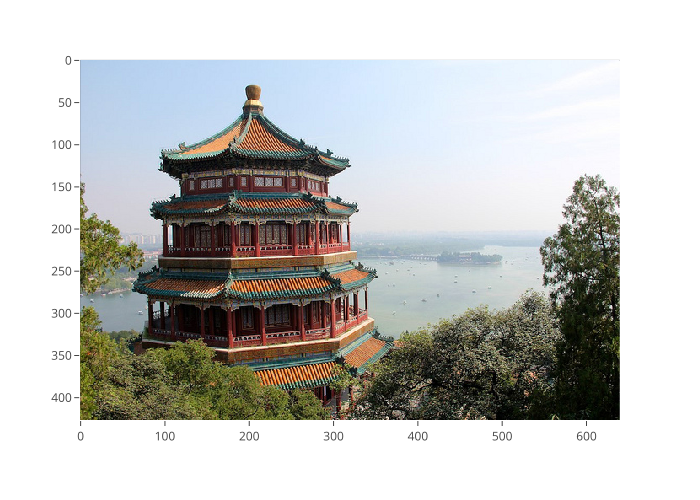

In [4]:
china_jpg = px.imshow(china)
china_jpg

  3. Look at the dataset's shape

In [8]:
china.shape

(427, 640, 3)

----> Our dataset is split between the height of the pixel, the width of the pixel and its color in RGB

4. Divide your dataset by 255 then resize it in two dimensions (length x width, RGB).

  a. Hint: You can use the ```.reshape()``` method.

In [10]:
normalized_value = china / 255

In [12]:
normalized_value[:,5]

array([[0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       ...,
       [0.29803922, 0.29803922, 0.01568627],
       [0.34509804, 0.35294118, 0.06666667],
       [0.40784314, 0.41568627, 0.12156863]])

In [ ]:
# data = china / 255
# data = data.reshape(427 * 640, 3)
# data.shape

X_reshaped = normalized_value.reshape(-1, 3)

X_reshaped.shape

(273280, 3)

5. We will reduce the number of colours to 16. To do this create a KMeans algorithm that will take 16 clusters.


Instead of using KMeans, you can use [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html)

In [23]:
kmeans = KMeans(n_clusters=16, random_state=0)
kmeans.fit(X_reshaped)

c:\Users\briic\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\briic\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\briic\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\briic\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KMeans(n_clusters=16, random_state=0)

6. For each of the colors present in your dataset, reassign the color code of the centroid of the corresponding cluster in a variable that we will call _new_colors_ .

In [ ]:
# new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

In [26]:
new_colors = kmeans.cluster_centers_
new_colors

array([[0.90146186, 0.90531977, 0.9157502 ],
       [0.29802968, 0.3029035 , 0.25576755],
       [0.608298  , 0.64893919, 0.63498571],
       [0.73523194, 0.76857465, 0.76038533],
       [0.42929974, 0.39356339, 0.19529073],
       [0.04972396, 0.04731774, 0.02510994],
       [0.76818892, 0.83160316, 0.90594173],
       [0.94425619, 0.9622822 , 0.98992475],
       [0.61121908, 0.4603809 , 0.29435268],
       [0.83594881, 0.90893558, 0.98563271],
       [0.20584905, 0.20703433, 0.15895009],
       [0.41524639, 0.41936087, 0.36087453],
       [0.14221145, 0.11666033, 0.08484137],
       [0.85360537, 0.61090721, 0.446018  ],
       [0.53109254, 0.54018874, 0.47189347],
       [0.36245222, 0.2265106 , 0.11978807]])

7. Resize _new_colors_ to 3 dimensions

In [ ]:
# china_recolored = new_colors.reshape(china.shape)

In [27]:
new_colors.shape

(16, 3)

In [37]:
labels = kmeans.labels_
reconstructed_flat = new_colors[labels]
print(reconstructed_flat.shape)
image_recontructed = reconstructed_flat.reshape(427, 640, 3)
image_recontructed

(273280, 3)


array([[[0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        ...,
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475]],

       [[0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        ...,
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475]],

       [[0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        [0.76818892, 0.83160316, 0.90594173],
        ...,
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475],
        [0.94425619, 0.9622822 , 0.98992475]],

       ...,

       [[0.36245222, 0.2265106 , 0.11978807],
        [0.61121908, 0.4603809 , 0.29435268],
        [0.42929974, 0

8. Visualize your new image with your variable _new_colors_.

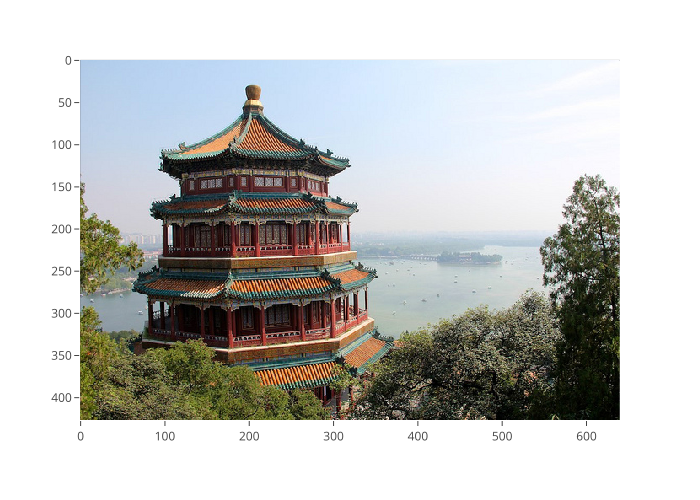

In [38]:
china_jpg

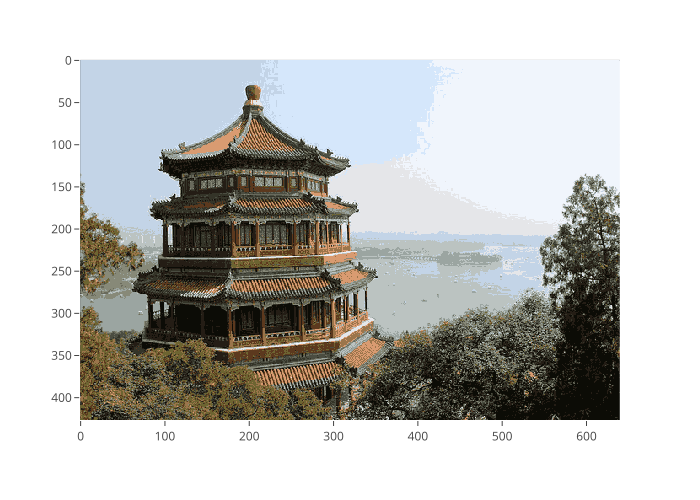

In [40]:
china_jpg_rec = px.imshow(image_recontructed)
china_jpg_rec